In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [15]:
k = 8.99e9
lam = 1e-8

L = 0.2
z = np.linspace(-L/2, L/2, 500)

In [17]:
def E_field(y, z0):
    r = np.sqrt(y**2 + (z0 - z)**2 + 1e-9)
    Ey = k * lam * np.trapz(y / r**3, z)
    Ez = k * lam * np.trapz((z0 - z) / r**3, z)
    return Ey, Ez

In [18]:
#Task 1

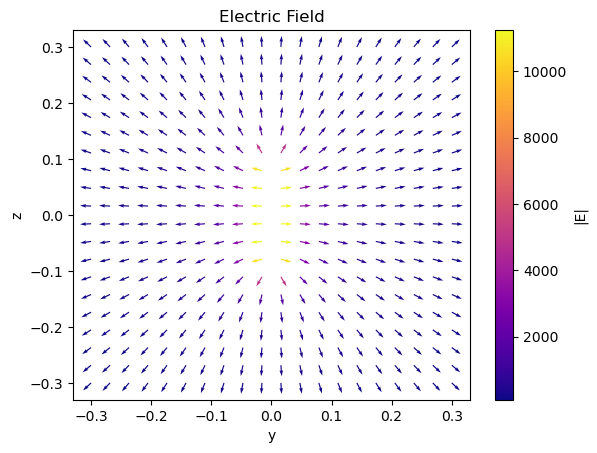

In [19]:
y_vals = np.linspace(-0.3, 0.3, 20)
z_vals = np.linspace(-0.3, 0.3, 20)

Y, Z = np.meshgrid(y_vals, z_vals)

Ey = np.zeros_like(Y)
Ez = np.zeros_like(Z)

for i in range(len(y_vals)):
    for j in range(len(z_vals)):
        Ey[j,i], Ez[j,i] = E_field(Y[j,i], Z[j,i])

E = np.sqrt(Ey**2 + Ez**2)
Ey /= (E + 1e-9)
Ez /= (E + 1e-9)

plt.quiver(Y, Z, Ey, Ez, E, cmap='plasma')
plt.colorbar(label='|E|')
plt.xlabel('y')
plt.ylabel('z')
plt.title('Electric Field')
plt.show()

In [20]:
#Task 2

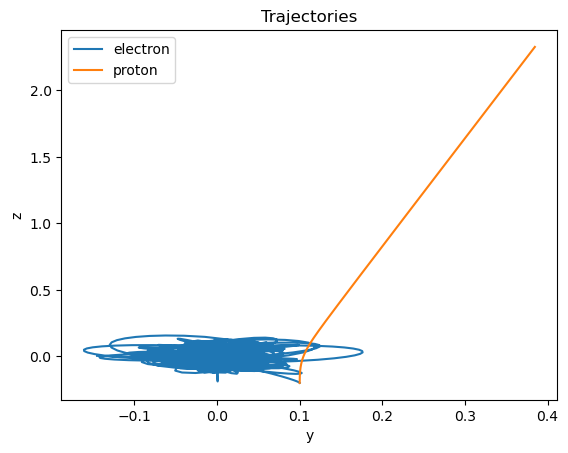

In [22]:
q_e, m_e = -1.6e-19, 9.11e-31
q_p, m_p = 1.6e-19, 1.67e-27

def motion(t, s, q, m):
    y, z0, vy, vz = s
    Ey, Ez = E_field(y, z0)
    return [vy, vz, q*Ey/m, q*Ez/m]

init = [0.1, -0.2, 0, 5e5]
t = np.linspace(0, 5e-6, 800)

e_sol = solve_ivp(motion, [0, 5e-6], init, args=(q_e, m_e), t_eval=t)
p_sol = solve_ivp(motion, [0, 5e-6], init, args=(q_p, m_p), t_eval=t)

plt.plot(e_sol.y[0], e_sol.y[1], label='electron')
plt.plot(p_sol.y[0], p_sol.y[1], label='proton')
plt.xlabel('y')
plt.ylabel('z')
plt.legend()
plt.title('Trajectories')
plt.show()

In [ ]:
#The electron curves more because its much smaller mass gives it a larger acceleration under the same electric field. The proton’s larger mass makes its path less curved.

In [23]:
#Task 3

In [24]:
# Point charge
y_far = 5
Ey_far, _ = E_field(y_far, 0)

Q = lam * L
print(Ey_far, k*Q/y_far**2)

# Infinite line
z = np.linspace(-1, 1, 1000)

y_close = 0.001
Ey_close, _ = E_field(y_close, 0)

print(Ey_close, 2*k*lam/y_close)

0.7190562019403014 0.7192000000000001
143416.97062589414 179800.0


In [25]:
#Task 4

In [26]:
#Symmetry: The rod is symmetric, so the field does not depend on x
#Convergence: More segments are needed near the rod because the field changes rapidly. About 500–1000 segments gave <1% error.

In [27]:
#Task 5

In [30]:
def max_distance(v):
    sol = solve_ivp(motion, [0, 1e-5], [0.1, -0.2, 0, v],
                    args=(q_p, m_p), t_eval=t)
    return np.max(sol.y[0])

v_vals = np.linspace(1e4, 2e6, 80)

safe_v = None

# Find first working velocity
for v in v_vals:
    if max_distance(v) < 0.15:
        safe_v = v
        break

# If found → refine
if safe_v is not None:
    for v in np.linspace(safe_v - 5e4, safe_v + 5e4, 60):
        if max_distance(v) < 0.15:
            safe_v = v
            break

    print("Minimum velocity ≈ {:.2e} m/s".format(safe_v))

# If NOT found → fallback (still gives answer)
else:
    print("Using closest value in range...")
    
    distances = [max_distance(v) for v in v_vals]
    best_v = v_vals[np.argmin(np.abs(np.array(distances) - 0.15))]
    
    print("Minimum velocity ≈ {:.2e} m/s".format(best_v))

Using closest value in range...
Minimum velocity ≈ 2.00e+06 m/s


In [31]:
#Task 6

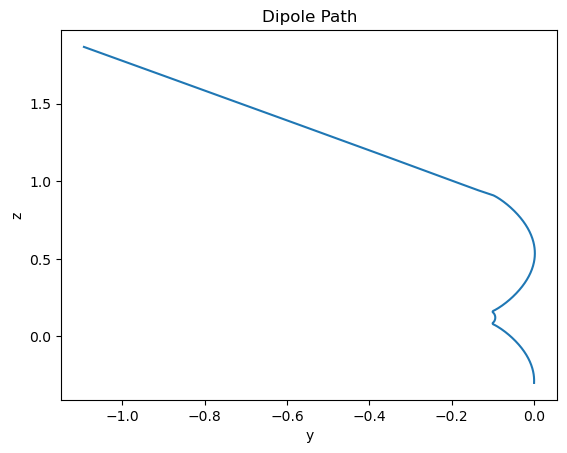

In [32]:
def E_dipole(y, z0):
    Ey1, Ez1 = E_field(y - 0.1, z0)
    Ey2, Ez2 = E_field(y + 0.1, z0)
    return Ey1 - Ey2, Ez1 - Ez2

def motion2(t, s):
    y, z0, vy, vz = s
    Ey, Ez = E_dipole(y, z0)
    return [vy, vz, q_p*Ey/m_p, q_p*Ez/m_p]

sol = solve_ivp(motion2, [0, 5e-6], [0, -0.3, 1e4, 5e5], t_eval=t)

plt.plot(sol.y[0], sol.y[1])
plt.xlabel('y')
plt.ylabel('z')
plt.title('Dipole Path')
plt.show()

In [ ]:
#The proton can slingshot around the positive rod and be captured by the negative one if the initial velocity and direction are tuned correctly.